In [1]:
import os
# Get the current working directory
current_dir = os.getcwd()
# Set the data directory to the parent directory of the current working directory
wdir = os.path.dirname(current_dir)
# Change the current working directory to the parent directory
os.chdir(wdir)

In [3]:
import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import glob


In [4]:
# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 9
rcParams['axes.titlesize'] = 9
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9

In [5]:
# define plotwidth
def cm2inch(x): return float(x)/2.54
plotwidth    = cm2inch(8.90)

In [6]:
# --------------------
# Load data
# --------------------
# find all CSV files
files = sorted(glob.glob("data/Supplementary_Fig_5/null_traj_*.csv"))

trajectories_null = []

for f in files:
    df = pd.read_csv(f)
    traj = df["value"].to_numpy()    # convert column to numpy array
    trajectories_null.append(traj)


files = sorted(glob.glob("data/Supplementary_Fig_5/no_jump_traj_*.csv"))

trajectories_no_jump = []

for f in files[0:1000]:
    df = pd.read_csv(f)
    traj = df["value"].to_numpy()    # convert column to numpy array
    trajectories_no_jump.append(traj)


files = sorted(glob.glob("data/Supplementary_Fig_5/jump_traj_*.csv"))

trajectories_jump = []

for f in files:
    df = pd.read_csv(f)
    traj = df["value"].to_numpy()    # convert column to numpy array
    trajectories_jump.append(traj)


files = sorted(glob.glob("data/Supplementary_Fig_5/time_of_jump_traj_*.csv"))

jump_times = []

for f in files:
    df = pd.read_csv(f)
    traj = df["value"].to_numpy()    # convert column to numpy array
    jump_times.append(traj)



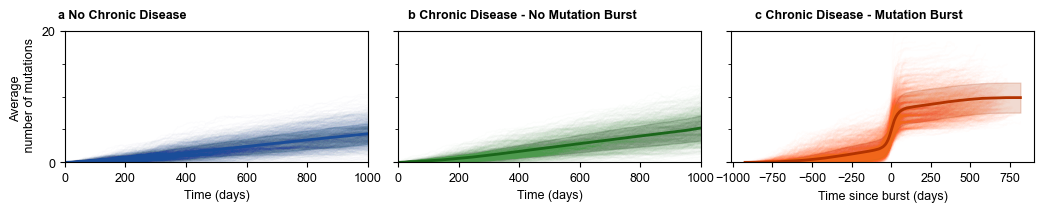

In [7]:
step=4
T=1000
def compute_mean_sd(trajs, step=None, shifted_times=None):
    """
    trajs: list of numpy arrays
    step: downsampling step for raw trajectories (panels 1 & 2)
    shifted_times: list of t_rel arrays (panel 3). If provided, we interpolate.
    """
    if shifted_times is None:
        # ----- Panels 1 and 2 -----
        # Downsample trajectories
        M = np.vstack([traj[0:T+1:step] for traj in trajs])  # shape (N, T/step)
        mean_vals = np.nanmean(M, axis=0)
        sd_vals   = np.nanstd(M, axis=0)
        x = np.arange(1, T+2, step)
        return x, mean_vals, sd_vals

    else:
        # ----- Panel 3: shifted trajectories -----
        # Create common time grid (union of all t_rel)
        tmin = min([t.min() for t in shifted_times])
        tmax = max([t.max() for t in shifted_times])
        grid = np.arange(tmin, tmax + 1)

        # interpolate all trajectories onto common grid
        M = []
        for traj, t_rel in zip(trajs, shifted_times):
            M.append(np.interp(grid, t_rel, traj))
        M = np.vstack(M)

        mean_vals = np.mean(M, axis=0)
        sd_vals   = np.std(M, axis=0)
        return grid, mean_vals, sd_vals


# ------------------------------------------------------------
# Make the layout
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(3*plotwidth, 0.5*plotwidth))


# -----------------------------
# Panel 1 — Null model
# -----------------------------
for traj in trajectories_null:
    axs[0].plot(
        np.arange(1, T+2, step),
        traj[0:T+1:step],
        color= (0.1, 0.3, 0.6),
        alpha=0.01,
        linewidth=1.0
    )

# Mean and SD
x1, m1, s1 = compute_mean_sd(trajectories_null, step=step)
axs[0].plot(x1, m1, color=(0.1, 0.3, 0.6), linewidth=2)
axs[0].fill_between(x1, m1 - s1, m1 + s1, alpha=0.18, color=(0.1, 0.3, 0.6))

axs[0].set_xlabel("Time (days)")
axs[0].set_ylabel("Average \n number of mutations")
axs[0].set_ylim(0, 20)
axs[0].set_xlim(0, 1001)
axs[0].grid(False)
axs[0].set_yticks([0, 20])
axs[0].set_yticks([5, 10, 15], minor=True)


# -----------------------------
# Panel 2 — Chronic disease, no burst
# -----------------------------
for traj in trajectories_no_jump:
    axs[1].plot(
        np.arange(1, T+2, step),
        traj[0:T+1:step],
        color=(0.3, 0.6, 0.3),
        alpha=0.01,
        linewidth=1.0
    )

# Mean and SD
x2, m2, s2 = compute_mean_sd(trajectories_no_jump, step=step)
axs[1].plot(x2, m2, color=(0.1, 0.4, 0.1), linewidth=2)
axs[1].fill_between(x2, m2 - s2, m2 + s2, alpha=0.18, color=(0.1, 0.4, 0.1))

axs[1].set_xlabel("Time (days)")
axs[1].set_ylabel("")
axs[1].set_ylim(0, 20)
axs[1].set_xlim(0, 1001)
axs[1].grid(False)
axs[1].set_yticks([0, 20])
axs[1].set_yticks([5, 10, 15], minor=True)
axs[1].set_yticklabels([])


# -----------------------------
# Panel 3 — Chronic disease with mutation burst
# -----------------------------
shifted_times = []
for traj, tb in zip(trajectories_jump, jump_times):
    t_rel = np.arange(len(traj)) - tb
    shifted_times.append(t_rel)
    axs[2].plot(
        t_rel, traj,
        lw=1,
        alpha=0.01,
        color=(1.0, 0.4, 0.1)
    )

# Mean and SD for shifted trajectories
x3, m3, s3 = compute_mean_sd(trajectories_jump, shifted_times=shifted_times)
axs[2].plot(x3, m3, color=(0.7, 0.2, 0.0), linewidth=2)
axs[2].fill_between(x3, m3 - s3, m3 + s3, alpha=0.18, color=(0.7, 0.2, 0.0))

axs[2].set_xlabel("Time since burst (days)")
axs[2].set_ylabel("")
axs[2].set_ylim(0, 20)
axs[2].grid(False)
axs[2].set_yticks([0, 20])
axs[2].set_yticks([5, 10, 15], minor=True)
axs[2].set_yticklabels([])


# -----------------------------
# Panel labels
# -----------------------------
fig.text(0.12, 0.99, 'a No Chronic Disease', ha='center', va='center', weight='bold')
fig.text(0.50, 0.99, 'b Chronic Disease - No Mutation Burst', ha='center', va='center', weight='bold')
fig.text(0.82, 0.99, 'c Chronic Disease - Mutation Burst', ha='center', va='center', weight='bold')

fig.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.90, wspace=0.1)
plt.show()
